# PDFs of extremes and anomaly thresholds from different models
climatology= sst-ssta
threshold extreme= it's the percentile

In [1]:
import xarray as xr
import numpy as np
import pandas as pd
import sys
import dask.dataframe as dd
from dask.distributed import wait
import matplotlib.lines as mlines
from scipy.ndimage import binary_closing as binary_closing
from scipy.ndimage import binary_opening as binary_opening
from scipy.ndimage import label as scipy_label
from scipy.ndimage import sum as scipy_sum
from skimage.measure import regionprops

import math
import os
import seaborn as sns
import intake
from scipy.stats import linregress
from scipy import stats
from dask import delayed
from IPython.display import display, HTML
import imageio
#from joblib import Parallel, delayed
import matplotlib.dates as mdates
import intake
from DV8_extremes import *
#DV8_functions(1) packages
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from matplotlib.animation import FFMpegWriter
from matplotlib import animation, rc
from IPython.display import HTML
#my functions:

#from dask_image.ndmorph import binary_opening, binary_closing 


import matplotlib.colors as mcolors

from tempfile import TemporaryDirectory
from getpass import getuser
from pathlib import Path
import dask
from dask.distributed import Client, LocalCluster
import bokeh
import subprocess
import re

import warnings
#warnings.filterwarnings('ignore')
scratch_dir = Path('/scratch') / getuser()[0] / getuser()

/home/b/b382616/.conda/envs/super_trooper/lib/python3.14/site-packages/pyproj/network.py:59: UserWarning: pyproj unable to set PROJ database path.
  _set_context_ca_bundle_path(ca_bundle_path)


In [2]:


dask.config.config.get('distributed').get('dashboard').update({'link':'{JUPYTERHUB_SERVICE_PREFIX}/proxy/{port}/status'})
cluster = LocalCluster(n_workers=32,threads_per_worker=1)
client = Client(cluster)
client

/home/b/b382616/.conda/envs/super_trooper/lib/python3.14/site-packages/distributed/node.py:188: UserWarning: Port 8787 is already in use.
Perhaps you already have a cluster running?
Hosting the HTTP server on port 41005 instead
  warnings.warn(


Connection method: Cluster object,Cluster type: distributed.LocalCluster
Dashboard: /user/b382616/levante-spawner-advanced//proxy/41005/status,
Dashboard: /user/b382616/levante-spawner-advanced//proxy/41005/status,Workers: 32
Total threads: 32,Total memory: 250.00 GiB
Status: running,Using processes: True
Comm: tcp://127.0.0.1:37639,Workers: 0
Dashboard: /user/b382616/levante-spawner-advanced//proxy/41005/status,Total threads: 0
Started: Just now,Total memory: 0 B
Comm: tcp://127.0.0.1:45795,Total threads: 1
Dashboard: /user/b382616/levante-spawner-advanced//proxy/41919/status,Memory: 7.81 GiB
Nanny: tcp://127.0.0.1:46135,


# LOAD DATA


In [3]:

def lon_180w_180e(ds_sice: xr.DataArray):
    ds_sice = (
        ds_sice
        .assign_coords(lon=lambda x: (x.lon - 180) % 360 - 180)
        .sortby('lon'))

    return ds_sice

In [4]:
#SST

# OSTIA
filename='/scratch/b/b382615/mhws/ostia.zarr' 
sst = xr.open_zarr(str(filename), chunks={'time':150, 'lat':-1, 'lon':-1}).sst
sst=sst.sel(lat=slice(-50, 70))
sst=sst-273.15

# ICON HISTORICAL
cat = intake.open_catalog("https://raw.githubusercontent.com/eerie-project/intake_catalogues/main/eerie.yaml")
dat = cat['dkrz.disk.model-output.icon-esm-er.hist-1950.v20240618.ocean.gr025']
sst_ic = dat['2d_daily_mean'](chunks={}).to_dask().to.isel(depth=0).drop_vars('depth').chunk({'time':150, 'lat':-1, 'lon':-1})
sst_ic=sst_ic.sel(lat=slice(-50, 70))


# IFS FESOM
cat = intake.open_catalog("https://raw.githubusercontent.com/eerie-project/intake_catalogues/main/eerie.yaml")
dat = cat['dkrz.disk.model-output.ifs-fesom2-sr.hist-1950.v20240304.ocean.gr025']#.icon-esm-er.hist-1950.v20240618.ocean.gr025']
sst_f = dat['2D_daily_avg_1950-2014'].to_dask().avg_tos.isel(depth=0).drop_vars('depth').chunk({'time':150, 'lat':-1, 'lon':-1})
sst_f=sst_f.sel(lat=slice(-50, 70))




#IFS NEMO
filename='/home/b/b382616/scratch/ifsnemo_hist_sst.zarr' 
sst_n = xr.open_zarr(str(filename), chunks={'time':30, 'lat':-1, 'lon':-1})
sst_n=sst_n.tos.chunk({'time':150, 'lat':-1, 'lon':-1})
sst_n=sst_n.sel(lat=slice(-50, 70))

file_name = Path('/scratch') / getuser()[0] / getuser()  / "mhws" / "IfsNemo_pre_1982_2014_FixedDetrend_hob_jan26.zarr"
chunks={'time': 150, 'lat': -1, 'lon': -1} #time=10 for 100GB #time=150 for 512GB
n_ds = xr.open_zarr(str(file_name), chunks=chunks)
n_ds=lon_180w_180e(n_ds)
sst_n=lon_180w_180e(sst_n)
n_ds = n_ds.sel(lat=slice(-50, 70))
nssta=n_ds['dat_anomaly']
sst_n=sst_n.sel(time=slice((nssta.time[0].values),str(nssta.time[-1].values)))
# Now apply the sea ice mask
nssta = nssta.where(sst_n > -1.7)

/tmp/ipykernel_3207770/3835719729.py:27: UserWarning: The specified chunks separate the stored chunks along dimension "time" starting at index 30. This could degrade performance. Instead, consider rechunking after loading.
  sst_n = xr.open_zarr(str(filename), chunks={'time':30, 'lat':-1, 'lon':-1})


In [5]:
# HADGEM LL
sst_LL = xr.open_dataset(
    '/home/b/b382616/scratch/mhws/hadgem/input_data/LL/toscon_nemo_u-da156_1d_19700101-20150101_grid-025.nc',
    chunks={'time': 150, 'lat': -1, 'lon': -1}  # Chunk by year, full spatial dimensions
)
sst_LL=sst_LL['toscon'].sel(lat=slice(-50, 70))


# HADGEM MM
sst_MM = xr.open_dataset(
    '/home/b/b382616/scratch/mhws/hadgem/input_data/MM/toscon_nemo_u-dc396_1d_19700101-20150101_grid-025.nc',
    chunks={'time': 150, 'lat': -1, 'lon': -1}  # Chunk by year, full spatial dimensions
)
sst_MM=sst_MM['toscon'].sel(lat=slice(-50, 70))


# HADGEM HH
sst_HH = xr.open_dataset(
    '/home/b/b382616/scratch/mhws/hadgem/input_data/HH/toscon_nemo_u-di356_1d_19700101-20150101_grid-025.nc',
    chunks={'time': 150, 'lat': -1, 'lon': -1}  # Chunk by year, full spatial dimensions
)
sst_HH=sst_HH['toscon'].sel(lat=slice(-50, 70))

            


/home/b/b382616/.conda/envs/super_trooper/lib/python3.14/site-packages/xarray/conventions.py:204: SerializationWarning: variable 'toscon' has multiple fill values {np.float32(1e+20), np.float64(1e+20)} defined, decoding all values to NaN.
  var = coder.decode(var, name=name)
/home/b/b382616/.conda/envs/super_trooper/lib/python3.14/site-packages/xarray/conventions.py:204: SerializationWarning: variable 'toscon' has multiple fill values {np.float32(1e+20), np.float64(1e+20)} defined, decoding all values to NaN.
  var = coder.decode(var, name=name)
/home/b/b382616/.conda/envs/super_trooper/lib/python3.14/site-packages/xarray/conventions.py:204: SerializationWarning: variable 'toscon' has multiple fill values {np.float32(1e+20), np.float64(1e+20)} defined, decoding all values to NaN.
  var = coder.decode(var, name=name)


## FIXED BASELINE

In [6]:
# FIXED BASELINES


# FIXED BASELINES

# OSTIA ANOMALIES
file_name = Path('/scratch') / getuser()[0] / getuser() / 'mhws' / 'OSTIA_pre_1982_2014_FixedDetrend_hob_oct25.zarr'
chunks={'time': 400, 'lat': -1, 'lon': -1} #time=10 for 100GB #time=150 for 512GB
ds = xr.open_zarr(str(file_name), chunks=chunks)
ds = ds.sel(lat=slice(-50, 70))
ossta=ds['dat_anomaly']
sst=sst.sel(time=slice((ossta.time[0].values),str(ossta.time[-1].values))) #making sure SST time matches SSTA time before masking the sea ice
ossta=ossta.where(sst>-1.7) #remove from anomalies places and times where there is sea ice



# ICON HIST ANOMALIES
file_name = Path('/scratch') / getuser()[0] / getuser() / 'mhws' / 'ICONhist_pre_1982_2014_FixedDetrend_hob_nov25.zarr'
chunks={'time': 150, 'lat': -1, 'lon': -1} #time=10 for 100GB #time=150 for 512GB
i_ds = xr.open_zarr(str(file_name), chunks=chunks)
i_ds=lon_180w_180e(i_ds)
sst_ic=lon_180w_180e(sst_ic)
i_ds = i_ds.sel(lat=slice(-50, 70))
issta=i_ds['dat_anomaly']
sst_ic=sst_ic.sel(time=slice(str(issta.time[0].values),str(issta.time[-1].values)))
# Now apply the sea ice mask
issta = issta.where(sst_ic > -1.7)



# IFS-FESOM ANOMALIES
file_name = Path('/scratch') / getuser()[0] / getuser() / 'mhws' / 'IfsFesom_pre_1982_2014_FixedDetrend_hob_nov25.zarr'
chunks={'time': 150, 'lat': -1, 'lon': -1} #time=10 for 100GB #time=150 for 512GB
f_ds = xr.open_zarr(str(file_name), chunks=chunks)
f_ds=lon_180w_180e(f_ds)
sst_f=lon_180w_180e(sst_f)
f_ds = f_ds.sel(lat=slice(-50, 70))
fssta=f_ds['dat_anomaly']
sst_f=sst_f.sel(time=slice((fssta.time[0].values),str(fssta.time[-1].values)))
# Now apply the sea ice mask
fssta = fssta.where(sst_f > -1.7)





# IFS-NEMO ANOMALIES
file_name = Path('/scratch') / getuser()[0] / getuser()  / "mhws" / "IfsNemo_pre_1982_2014_FixedDetrend_hob_jan26.zarr"
chunks={'time': 150, 'lat': -1, 'lon': -1} #time=10 for 100GB #time=150 for 512GB
n_ds = xr.open_zarr(str(file_name), chunks=chunks)
n_ds=lon_180w_180e(n_ds)
sst_n=lon_180w_180e(sst_n)
n_ds = n_ds.sel(lat=slice(-50, 70))
nssta=n_ds['dat_anomaly']
sst_n=sst_n.sel(time=slice((nssta.time[0].values),str(nssta.time[-1].values)))
# Now apply the sea ice mask
nssta = nssta.where(sst_n > -1.7)

In [7]:


# HADGEM LL ANOMALIES
file_name = Path('/scratch') / getuser()[0] / getuser() / 'mhws' / 'hadgem'/'marEx'/'LL'/'HadGEM3-LL_marEx_extremes_detrend_fixed_baseline_1982-2014.zarr'
chunks={'time': 150, 'lat': -1, 'lon': -1} #time=10 for 100GB #time=150 for 512GB
LL_ds = xr.open_zarr(str(file_name), chunks=chunks)
LL_ds=lon_180w_180e(LL_ds)
sst_LL=lon_180w_180e(sst_LL)
LL_ds = LL_ds.sel(lat=slice(-50, 70))
LLssta=LL_ds['dat_anomaly']
sst_LL=sst_LL.sel(time=slice((LLssta.time[0].values),str(LLssta.time[-1].values)))
# Now apply the sea ice mask
LLssta = LLssta.where(sst_LL > -1.7)

# HADGEM MM ANOMALIES
file_name = Path('/scratch') / getuser()[0] / getuser() / 'mhws' / 'hadgem'/'marEx'/'MM'/'HadGEM3-MM_marEx_extremes_detrend_fixed_baseline_1982-2014.zarr'
chunks={'time': 150, 'lat': -1, 'lon': -1} #time=10 for 100GB #time=150 for 512GB
MM_ds = xr.open_zarr(str(file_name), chunks=chunks)
MM_ds=lon_180w_180e(MM_ds)
sst_MM=lon_180w_180e(sst_MM)
MM_ds = MM_ds.sel(lat=slice(-50, 70))
MMssta=MM_ds['dat_anomaly']
sst_MM=sst_MM.sel(time=slice((MMssta.time[0].values),str(MMssta.time[-1].values)))
# Now apply the sea ice mask
MMssta = MMssta.where(sst_MM > -1.7)


# HADGEM HH ANOMALIES
file_name = Path('/scratch') / getuser()[0] / getuser() / 'mhws' / 'hadgem'/'marEx'/'HH'/'HadGEM3-HH_marEx_extremes_detrend_fixed_baseline_1982-2014.zarr'
chunks={'time': 150, 'lat': -1, 'lon': -1} #time=10 for 100GB #time=150 for 512GB
HH_ds = xr.open_zarr(str(file_name), chunks=chunks)
HH_ds=lon_180w_180e(HH_ds)
sst_HH=lon_180w_180e(sst_HH)
HH_ds = HH_ds.sel(lat=slice(-50, 70))
HHssta=HH_ds['dat_anomaly']
sst_HH=sst_HH.sel(time=slice((HHssta.time[0].values),str(HHssta.time[-1].values)))
# Now apply the sea ice mask
HHssta = HHssta.where(sst_HH> -1.7)


/tmp/ipykernel_3207770/481346273.py:4: UserWarning: The specified chunks separate the stored chunks along dimension "time" starting at index 150. This could degrade performance. Instead, consider rechunking after loading.
  LL_ds = xr.open_zarr(str(file_name), chunks=chunks)
/tmp/ipykernel_3207770/481346273.py:16: UserWarning: The specified chunks separate the stored chunks along dimension "time" starting at index 150. This could degrade performance. Instead, consider rechunking after loading.
  MM_ds = xr.open_zarr(str(file_name), chunks=chunks)
/tmp/ipykernel_3207770/481346273.py:29: UserWarning: The specified chunks separate the stored chunks along dimension "time" starting at index 150. This could degrade performance. Instead, consider rechunking after loading.
  HH_ds = xr.open_zarr(str(file_name), chunks=chunks)


In [8]:
# OSTIA EXTREMES
file_name = Path('/scratch') / getuser()[0] / getuser() / 'mhws' / 'OSTIA_pre_1982_2014_FixedDetrend_hob_oct25.zarr'
chunks={'time': 400, 'lat': -1, 'lon': -1} #time=10 for 100GB #time=150 for 512GB
ds = xr.open_zarr(str(file_name), chunks=chunks)
ds = ds.sel(lat=slice(-50, 70))
o_ex=ds['extreme_events']
sst=sst.sel(time=slice((o_ex.time[0].values),str(o_ex.time[-1].values)))





# ICON HIST EXTREMES
file_name = Path('/scratch') / getuser()[0] / getuser() / 'mhws' / 'ICONhist_pre_1982_2014_FixedDetrend_hob_nov25.zarr'
chunks={'time': 400, 'lat': -1, 'lon': -1} #time=10 for 100GB #time=150 for 512GB
i_ds = xr.open_zarr(str(file_name), chunks=chunks)
i_ds=lon_180w_180e(i_ds)
i_ds = i_ds.sel(lat=slice(-50, 70))
i_ex=i_ds['extreme_events']
sst_ic=sst_ic.sel(time=slice(str(i_ex.time[0].values),str(i_ex.time[-1].values)))

# For extreme events (boolean)
i_ex_float = i_ex.astype(float)  # Convert to 0.0 and 1.0
#i_ex_interp = i_ex_float.interp(lat=o_ex.lat, lon=o_ex.lon)
i_ex = i_ex_float > 0.5  # Convert back to boolean if needed





# IFS-FESOM EXTREMES
#file_name = Path('/scratch') / getuser()[0] / getuser() / 'mhws' / 'IfsFesom_pre_1982_2014_FixedDetrend_hob_nov25.zarr'
file_name = Path('/scratch') / getuser()[0] / getuser() / 'mhws' / 'IfsFesom_pre_1982_2014_FixedDetrend_hob_dec25.zarr'
chunks={'time': 400, 'lat': -1, 'lon': -1} #time=10 for 100GB #time=150 for 512GB
f_ds = xr.open_zarr(str(file_name), chunks=chunks)
f_ds=lon_180w_180e(f_ds)
f_ds = f_ds.sel(lat=slice(-50, 70))
f_ex=f_ds['extreme_events']
#fssta=f_ds['dat_anomaly']
#sst_f=sst_f.sel(time=slice((fssta.time[0].values),str(fssta.time[-1].values)))
# For extreme events (boolean)
f_ex_float = f_ex.astype(float)  # Convert to 0.0 and 1.0
#f_ex_interp = f_ex_float.interp(lat=o_ex.lat, lon=o_ex.lon)
f_ex = f_ex_float > 0.5  # Convert back to boolean if needed



# IFS-FESOM EXTREMES
#file_name = Path('/scratch') / getuser()[0] / getuser() / 'mhws' / 'IfsFesom_pre_1982_2014_FixedDetrend_hob_nov25.zarr'
file_name = Path('/scratch') / getuser()[0] / getuser() / 'mhws' / 'IfsFesom_pre_1982_2014_FixedDetrend_hob_dec25.zarr'
chunks={'time': 400, 'lat': -1, 'lon': -1} #time=10 for 100GB #time=150 for 512GB
f_ds = xr.open_zarr(str(file_name), chunks=chunks)
f_ds=lon_180w_180e(f_ds)
f_ds = f_ds.sel(lat=slice(-50, 70))
f_ex=f_ds['extreme_events']
#fssta=f_ds['dat_anomaly']
#sst_f=sst_f.sel(time=slice((fssta.time[0].values),str(fssta.time[-1].values)))
# For extreme events (boolean)
f_ex_float = f_ex.astype(float)  # Convert to 0.0 and 1.0
#f_ex_interp = f_ex_float.interp(lat=o_ex.lat, lon=o_ex.lon)
f_ex = f_ex_float > 0.5  # Convert back to boolean if needed

# IFS-NEMO EXTREMES
file_name = Path('/scratch') / getuser()[0] / getuser()  / "mhws" / "IfsNemo_pre_1982_2014_FixedDetrend_hob_jan26.zarr"
chunks={'time': 150, 'lat': -1, 'lon': -1} #time=10 for 100GB #time=150 for 512GB
n_ds = xr.open_zarr(str(file_name), chunks=chunks)
n_ds=lon_180w_180e(n_ds)
n_ds = n_ds.sel(lat=slice(-50, 70))
n_ex=n_ds['extreme_events']
n_ex_float = n_ex.astype(float) 
n_ex = n_ex_float > 0.5 

In [9]:


# HADGEM LL EXTREMES
file_name = Path('/scratch') / getuser()[0] / getuser() / 'mhws' / 'hadgem'/'marEx'/'LL'/'HadGEM3-LL_marEx_extremes_detrend_fixed_baseline_1982-2014.zarr'
chunks={'time': 150, 'lat': -1, 'lon': -1} #time=10 for 100GB #time=150 for 512GB
LL_ds = xr.open_zarr(str(file_name), chunks=chunks)
LL_ds=lon_180w_180e(LL_ds)
sst_LL=lon_180w_180e(sst_LL)
LL_ds = LL_ds.sel(lat=slice(-50, 70))
LL_ex=LL_ds['extreme_events']
#LLssta=LL_ds['dat_anomaly']
LL_ex_float = LL_ex.astype(float) 
LL_ex = LL_ex_float > 0.5 

# HADGEM MM EXTREMES
file_name = Path('/scratch') / getuser()[0] / getuser() / 'mhws' / 'hadgem'/'marEx'/'MM'/'HadGEM3-MM_marEx_extremes_detrend_fixed_baseline_1982-2014.zarr'
chunks={'time': 150, 'lat': -1, 'lon': -1} #time=10 for 100GB #time=150 for 512GB
MM_ds = xr.open_zarr(str(file_name), chunks=chunks)
MM_ds=lon_180w_180e(MM_ds)
sst_MM=lon_180w_180e(sst_MM)
MM_ds = MM_ds.sel(lat=slice(-50, 70))
MM_ex=MM_ds['extreme_events']
#MMssta=MM_ds['dat_anomaly']
MM_ex_float = MM_ex.astype(float) 
MM_ex = MM_ex_float > 0.5 


# HADGEM HH EXTREMES
file_name = Path('/scratch') / getuser()[0] / getuser() / 'mhws' / 'hadgem'/'marEx'/'HH'/'HadGEM3-HH_marEx_extremes_detrend_fixed_baseline_1982-2014.zarr'
chunks={'time': 150, 'lat': -1, 'lon': -1} #time=10 for 100GB #time=150 for 512GB
HH_ds = xr.open_zarr(str(file_name), chunks=chunks)
HH_ds=lon_180w_180e(HH_ds)
sst_HH=lon_180w_180e(sst_HH)
HH_ds = HH_ds.sel(lat=slice(-50, 70))
HH_ex=HH_ds['extreme_events']
#HHssta=HH_ds['dat_anomaly']
HH_ex_float = HH_ex.astype(float) 
HH_ex = HH_ex_float > 0.5 


/tmp/ipykernel_3207770/3477229959.py:4: UserWarning: The specified chunks separate the stored chunks along dimension "time" starting at index 150. This could degrade performance. Instead, consider rechunking after loading.
  LL_ds = xr.open_zarr(str(file_name), chunks=chunks)
/tmp/ipykernel_3207770/3477229959.py:16: UserWarning: The specified chunks separate the stored chunks along dimension "time" starting at index 150. This could degrade performance. Instead, consider rechunking after loading.
  MM_ds = xr.open_zarr(str(file_name), chunks=chunks)
/tmp/ipykernel_3207770/3477229959.py:29: UserWarning: The specified chunks separate the stored chunks along dimension "time" starting at index 150. This could degrade performance. Instead, consider rechunking after loading.
  HH_ds = xr.open_zarr(str(file_name), chunks=chunks)


# REMOVE SEA ICE FROM SST
### we need to remove sea ice from sst after loading all the other variables, because otherwise we are inferring the climatology from places where ssta has no sea ice but sst does, which can result in a climaotlogy that is way too negative

In [10]:
#SST

# OSTIA
sst=sst.where(sst> -1.7)


# ICON HISTORICAL
sst_ic=sst_ic.where(sst_ic> -1.7)


# IFS FESOM
sst_f=sst_f.where(sst_f> -1.7)

# IFS NEMO
sst_n=sst_n.where(sst_n> -1.7)



# HADGEM LL
sst_LL=sst_LL.where(sst_LL> -1.7)


# HADGEM MM
sst_MM=sst_MM.where(sst_MM> -1.7)


# HADGEM HH

sst_HH = sst_HH.where(sst_HH> -1.7)
            


# compute PDFs

In [11]:
# LOAD MASKS
all_models = ['OSTIA', 'ICON', 'IFS-FESOM','IFS-NEMO', 'HadGEM3-HH','HadGEM3-MM','HadGEM3-LL']

mask_save_dir = Path('/scratch/b/b382616/mhws/DV8/extremes_model_masks')

# All model names

masks_dict = {}

for model in all_models:
    # Find the mask file for this model
    mask_files = list(mask_save_dir.glob(f'*{model}*.zarr'))
    
    if mask_files:
        mask_file = mask_files[0]
        print(f"Loading {model} mask from {mask_file.name}")
        
        mask_ds = xr.open_zarr(str(mask_file))
        
        # For HadGEM models, select latitude range
        if model.startswith('HadGEM3-'):
            mask_ds = mask_ds.sel(lat=slice(-50, 70))
            print(f"  Selected lat range -50 to 70")
        
        masks_dict[model] = mask_ds
        print(f"  ✓ Loaded {len(mask_ds.data_vars)} regions")
    else:
        print(f"Warning: No mask file found for {model}")

print(f"\nSuccessfully loaded masks for {len(masks_dict)} models")

Loading OSTIA mask from extremes_OSTIA_480x1440_8350716742437587350_region_masks.zarr
  ✓ Loaded 15 regions
Loading ICON mask from extremes_ICON_481x1440_-2130404455801615551_region_masks.zarr
  ✓ Loaded 15 regions
Loading IFS-FESOM mask from extremes_IFS-FESOM_481x1440_-2130404455801615551_region_masks.zarr
  ✓ Loaded 15 regions
Loading IFS-NEMO mask from extremes_IFS-NEMO_481x1440_-2130404455801615551_region_masks.zarr
  ✓ Loaded 15 regions
Loading HadGEM3-HH mask from extremes_HadGEM3-HH_721x1440_-4232089158561518125_region_masks.zarr
  Selected lat range -50 to 70
  ✓ Loaded 15 regions
Loading HadGEM3-MM mask from extremes_HadGEM3-MM_721x1440_-4232089158561518125_region_masks.zarr
  Selected lat range -50 to 70
  ✓ Loaded 15 regions
Loading HadGEM3-LL mask from extremes_HadGEM3-LL_721x1440_-4232089158561518125_region_masks.zarr
  Selected lat range -50 to 70
  ✓ Loaded 15 regions

Successfully loaded masks for 7 models


# threshold pdfs

In [12]:
model_data_mapping = {
    'OSTIA': {
        'sst': sst,
        'ssta': ossta,
        'thresholds': ds.thresholds

    },
    'ICON': {
        'sst': sst_ic,
        'ssta': issta,
        'thresholds': i_ds.thresholds

    },
    'IFS-FESOM': {
        'sst': sst_f,
        'ssta': fssta,
        'thresholds': f_ds.thresholds

    },

    'IFS-NEMO': {
        'sst': sst_n,
        'ssta': nssta,
        'thresholds': n_ds.thresholds

    },
    'HadGEM3-HH': {
        'sst': sst_HH,
        'ssta': HHssta,
        'thresholds': HH_ds.thresholds

    },
    'HadGEM3-MM': {
        'sst': sst_MM,
        'ssta': MMssta,
        'thresholds': MM_ds.thresholds

    },
    'HadGEM3-LL': {
        'sst': sst_LL,
        'ssta': LLssta,
        'thresholds': LL_ds.thresholds

    }
}

In [ ]:
# GLOBAL

# --- 1. CONFIGURATION ---
# We use the same styles for consistency
styles = {
    'OSTIA':      {'color': 'black',     'ls': '-',  'lw': 3.0, 'zorder': 10},
    'ICON':       {'color': 'blue',      'ls': '-',  'lw': 2,   'zorder': 9},
    'IFS-FESOM':  {'color': 'red',       'ls': '-',  'lw': 2,   'zorder': 8},
    'IFS-NEMO':   {'color': 'green',     'ls': '-',  'lw': 2,   'zorder': 7},
    'HadGEM3-HH': {'color': 'orange',    'ls': '-',  'lw': 2,   'zorder': 6},
    'HadGEM3-MM': {'color': 'brown',     'ls': '--', 'lw': 1.5, 'zorder': 5},
    'HadGEM3-LL': {'color': 'rosybrown', 'ls': '--', 'lw': 1.5, 'zorder': 4}
}

sst_bins = np.linspace(-2, 35, 101)
bin_centers = 0.5 * (sst_bins[1:] + sst_bins[:-1])

# --- 2. INITIALIZE PLOT ---
fig, ax = plt.subplots(figsize=(12, 6))

# --- 3. COMPUTATION LOOP ---
for model_name in styles.keys():
    if model_name not in model_data_mapping: continue
    
    print(f"Computing Global PDF for {model_name}...")
    s = styles[model_name]
    
    # Extract threshold data (Global)
    # Note: We don't apply thinning here for the final global plot 
    # unless memory is an issue, to get the most accurate distribution.
    thr_global = model_data_mapping[model_name]['thresholds']
    
    # Histogram of all non-NaN values (Ocean only)
    # .data allows dask to handle the flattening efficiently
    ht_t, _ = da.histogram(thr_global.data, bins=sst_bins, range=(-2, 35))
    ht = ht_t.compute()
    
    # Normalize to Density
    bw = sst_bins[1] - sst_bins[0]
    y_t = ht / (ht.sum() * bw) if ht.sum() > 0 else np.zeros_like(bin_centers)

    # Plot
    ax.plot(bin_centers, y_t, label=model_name, 
            color=s['color'], ls=s['ls'], lw=s['lw'], zorder=s['zorder'])

# --- 4. FINAL STYLING ---
ax.set_xlim(-1, 5)
ax.set_ylim(bottom=0)
ax.set_title("Global Ocean: Extreme Threshold Density", fontsize=16, fontweight='bold')
ax.set_xlabel("SST Threshold (°C)", fontsize=12)
ax.set_ylabel("Probability Density", fontsize=12)
ax.grid(True, alpha=0.2, linestyle='--')

# Place legend in the top right
ax.legend(loc='upper right', frameon=False, fontsize=11)

plt.tight_layout()
plt.show()

Computing Global PDF for OSTIA...
Computing Global PDF for ICON...


In [ ]:
# REGIONAL


model_order = ['OSTIA', 'ICON', 'IFS-FESOM', 'IFS-NEMO', 'HadGEM3-HH', 'HadGEM3-MM', 'HadGEM3-LL']


# --- 1. CONFIGURATION ---
all_regions = [var for var in masks_dict['OSTIA'].data_vars if var != 'spatial_ref']
n_cols = 3  # Adjust this to 3 if you have many regions
n_rows = math.ceil(len(all_regions) / n_cols)

styles = {
    'OSTIA':      {'color': 'black',     'ls': '-',  'lw': 2.5, 'zorder': 10},
    'ICON':       {'color': 'blue',      'ls': '-',  'lw': 2,   'zorder': 9},
    'IFS-FESOM':  {'color': 'red',       'ls': '-',  'lw': 2,   'zorder': 8},
    'IFS-NEMO':   {'color': 'green',     'ls': '-',  'lw': 2,   'zorder': 7},
    'HadGEM3-HH': {'color': 'orange',    'ls': '-',  'lw': 2,   'zorder': 6},
    'HadGEM3-MM': {'color': 'brown',     'ls': '--', 'lw': 1.5, 'zorder': 5},
    'HadGEM3-LL': {'color': 'rosybrown', 'ls': '--', 'lw': 1.5, 'zorder': 4}
}

sst_bins = np.linspace(-2, 35, 101)
bin_centers = 0.5 * (sst_bins[1:] + sst_bins[:-1])
SPACE_THIN = 5 

# --- 2. INITIALIZE GRID PLOT ---
fig, axes = plt.subplots(n_rows, n_cols, 
                         figsize=(n_cols * 7, n_rows * 4), 
                         constrained_layout=True)
axes_flat = axes.flatten()

# --- 3. PRE-LOAD MASKS ---
print(f"Pre-loading {len(all_regions)} regions into memory...")
local_masks = {}
for m in model_order:
    if m in masks_dict:
        local_masks[m] = masks_dict[m].isel(
            lat=slice(None, None, SPACE_THIN), 
            lon=slice(None, None, SPACE_THIN)
        ).compute()

# --- 4. COMPUTATION & PLOTTING LOOP ---
for model_name in styles.keys():
    if model_name not in model_data_mapping: continue
    
    print(f"Processing {model_name}...")
    s = styles[model_name]
    
    # Thin and persist threshold data for the model
    thr_full = model_data_mapping[model_name]['thresholds'].isel(
        lat=slice(None, None, SPACE_THIN), 
        lon=slice(None, None, SPACE_THIN)
    ).persist()
    
    wait([thr_full])
    
    for i, region_var in enumerate(all_regions):
        ax = axes_flat[i]
        
        mask = local_masks[model_name][region_var]
        t_reg = thr_full.where(mask)

        # Histogram calculation
        ht_t, _ = da.histogram(t_reg.data, bins=sst_bins, range=(-2, 35))
        ht = ht_t.compute()
        
        # Density normalization
        bw = sst_bins[1] - sst_bins[0]
        y_t = ht / (ht.sum() * bw) if ht.sum() > 0 else np.zeros_like(bin_centers)

        ax.plot(bin_centers, y_t, label=model_name, 
                color=s['color'], ls=s['ls'], lw=s['lw'], zorder=s['zorder'])

# --- 5. FINAL STYLING & CLEANUP ---
for i in range(len(axes_flat)):
    ax = axes_flat[i]
    if i < len(all_regions):
        # ... (keep your existing styling code here) ...
        ax.set_xlim(-1, 5)
        ax.set_title(all_regions[i].replace('_', ' '), fontsize=14, fontweight='bold')
    else:
        ax.axis('off')

# Create a single legend for the whole figure
# loc='upper right' puts it at the top right of the figure box
handles, labels = axes_flat[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='upper right', bbox_to_anchor=(0.98, 0.98), 
           frameon=False, fontsize=12)

plt.show()

Pre-loading 15 regions into memory...
Processing OSTIA...
Processing ICON...
Processing IFS-FESOM...


Pre-loading masks for Western & Eastern Pacific...
Processing OSTIA...


2026-01-03 11:34:55,161 - distributed.worker - ERROR - Worker stream died during communication: tcp://127.0.0.1:32783
Traceback (most recent call last):
  File "/home/b/b382616/.conda/envs/super_trooper/lib/python3.14/site-packages/distributed/comm/tcp.py", line 228, in read
    frames_nosplit = await read_bytes_rw(stream, frames_nosplit_nbytes)
                     ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/home/b/b382616/.conda/envs/super_trooper/lib/python3.14/site-packages/distributed/comm/tcp.py", line 367, in read_bytes_rw
    actual = await stream.read_into(chunk)  # type: ignore[arg-type]
             ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
tornado.iostream.StreamClosedError: Stream is closed

The above exception was the direct cause of the following exception:

Traceback (most recent call last):
  File "/home/b/b382616/.conda/envs/super_trooper/lib/python3.14/site-packages/distributed/worker.py", line 2081, in gather_dep
    response = await get_data_from_worker(
      

Processing ICON...
Processing IFS-FESOM...
Processing HadGEM3-LL...


2026-01-03 11:38:07,839 - distributed.worker.memory - WARNING - Worker is at 83% memory usage. Pausing worker.  Process memory: 6.55 GiB -- Worker memory limit: 7.81 GiB
2026-01-03 11:38:10,272 - distributed.worker.memory - WARNING - Worker is at 78% memory usage. Resuming worker. Process memory: 6.15 GiB -- Worker memory limit: 7.81 GiB
2026-01-03 11:38:15,820 - distributed.worker.memory - WARNING - Unmanaged memory use is high. This may indicate a memory leak or the memory may not be released to the OS; see https://distributed.dask.org/en/latest/worker-memory.html#memory-not-released-back-to-the-os for more information. -- Unmanaged memory: 5.70 GiB -- Worker memory limit: 7.81 GiB


Processing HadGEM3-MM...
Processing HadGEM3-HH...


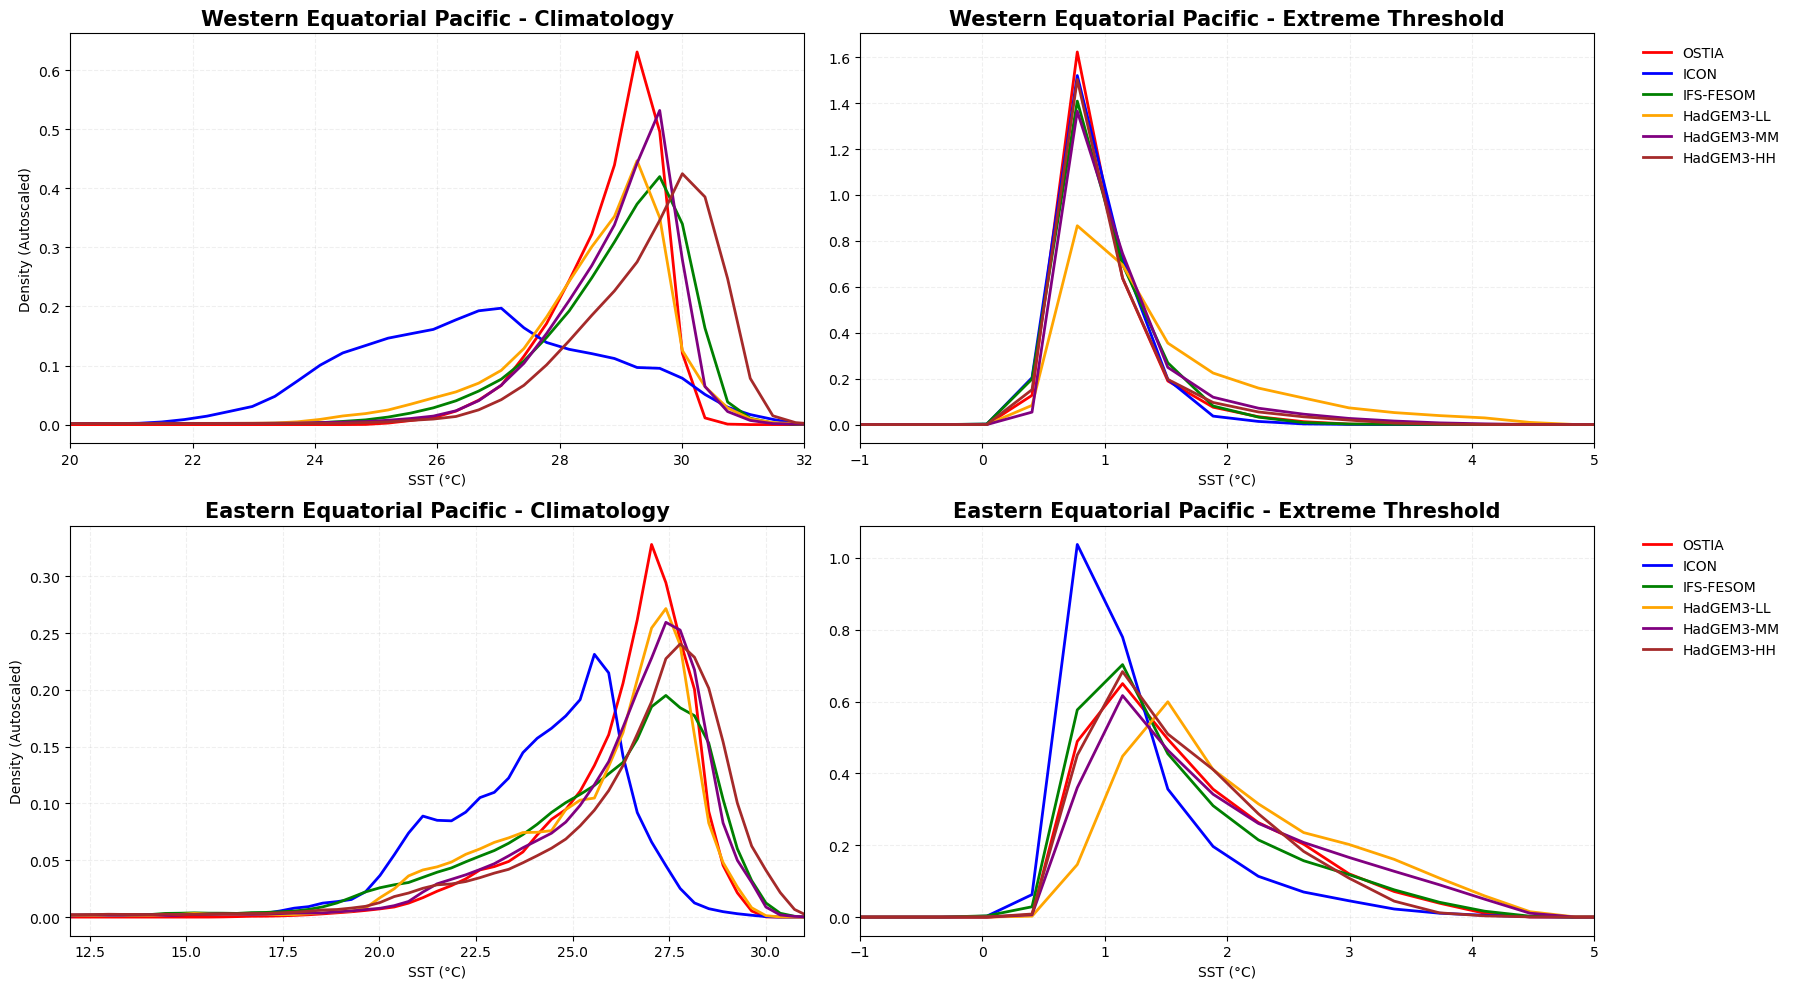

In [18]:
#CLIMATOLOGY

# --- 1. CONFIGURATION & SPECIFIC REGIONS ---
model_order = ['OSTIA', 'ICON', 'IFS-FESOM', 'IFS-NEMO', 'HadGEM3-HH', 'HadGEM3-MM', 'HadGEM3-LL']
colors = ['red', 'blue', 'green', 'orange', 'purple', 'brown']
color_map = dict(zip(model_order, colors))

# ONLY target these two regions
plot_regions = ['Western_Equatorial_Pacific', 'Eastern_Equatorial_Pacific']

# --- 2. SETTINGS & INDEPENDENT X-LIMITS ---
TIME_THIN = 10  
SPACE_THIN = 5  
sst_bins = np.linspace(-2, 35, 101)
bin_centers = 0.5 * (sst_bins[1:] + sst_bins[:-1])

# Added specific zooms for the new regions
regional_zooms = {
    'Western_Equatorial_Pacific': {'clim': (20, 32), 'thr': (-1, 5)},
    'Eastern_Equatorial_Pacific': {'clim': (12, 31), 'thr': (-1, 5)},
}
# Fallback dictionary
x_limits_config = {'Global': {'clim': (-2, 35), 'thr': (-2, 35)}}
x_limits_config.update(regional_zooms)

# --- 3. INITIALIZE PLOT (Full Autoscale on Y-axis) ---
fig, axes = plt.subplots(len(plot_regions), 2, 
                         figsize=(18, 5 * len(plot_regions)), 
                         sharex=False, 
                         sharey=False) 

# --- 4. PRE-LOAD MASKS ---
print("Pre-loading masks for Western & Eastern Pacific...")
local_masks = {}
for m in masks_dict:
    # Ensure we only compute the masks we need for these 2 regions to save time
    local_masks[m] = masks_dict[m][plot_regions].isel(
        lat=slice(None, None, SPACE_THIN), 
        lon=slice(None, None, SPACE_THIN)
    ).compute()

# --- 5. COMPUTATION LOOP ---
for model_name in model_order:
    if model_name not in model_data_mapping: continue
    
    print(f"Processing {model_name}...")
    d_dict = model_data_mapping[model_name]
    
    clim_full = (d_dict['sst'] - d_dict['ssta']).isel(
        time=slice(None, None, TIME_THIN), 
        lat=slice(None, None, SPACE_THIN), 
        lon=slice(None, None, SPACE_THIN)
    ).persist()
    
    thr_full = d_dict['thresholds'].isel(
        lat=slice(None, None, SPACE_THIN), 
        lon=slice(None, None, SPACE_THIN)
    ).persist()
    
    wait([clim_full, thr_full]) 
    
    for i, region in enumerate(plot_regions):
        # Handle the case if the plot only has one row
        ax_clim = axes[i, 0] if len(plot_regions) > 1 else axes[0]
        ax_thr = axes[i, 1] if len(plot_regions) > 1 else axes[1]
        
        mask = local_masks[model_name][region]
        c_reg = clim_full.where(mask)
        t_reg = thr_full.where(mask)

        hc_t, _ = da.histogram(c_reg.data, bins=sst_bins, range=(-2, 35))
        ht_t, _ = da.histogram(t_reg.data, bins=sst_bins, range=(-2, 35))
        hc, ht = da.compute(hc_t, ht_t)
        
        bw = sst_bins[1] - sst_bins[0]
        y_c = hc / (hc.sum() * bw) if hc.sum() > 0 else np.zeros_like(bin_centers)
        y_t = ht / (ht.sum() * bw) if ht.sum() > 0 else np.zeros_like(bin_centers)

        color = color_map.get(model_name, 'black')
        ax_clim.plot(bin_centers, y_c, label=model_name, color=color, lw=2.0)
        ax_thr.plot(bin_centers, y_t, label=model_name, color=color, lw=2.0)

# --- 6. FINAL STYLING ---
for i, region in enumerate(plot_regions):
    ax_clim = axes[i, 0] if len(plot_regions) > 1 else axes[0]
    ax_thr = axes[i, 1] if len(plot_regions) > 1 else axes[1]
    
    config = x_limits_config.get(region, x_limits_config['Global'])
    
    # Apply Individual Zooms
    ax_clim.set_xlim(config['clim'])
    ax_thr.set_xlim(config['thr'])
    
    # Titles & Labels
    clean_name = region.replace('_', ' ')
    ax_clim.set_title(f"{clean_name} - Climatology", fontsize=15, fontweight='bold')
    ax_thr.set_title(f"{clean_name} - Extreme Threshold", fontsize=15, fontweight='bold')
    
    ax_clim.set_ylabel("Density (Autoscaled)")
    ax_clim.set_xlabel("SST (°C)")
    ax_thr.set_xlabel("SST (°C)")
    
    ax_clim.grid(True, alpha=0.2, linestyle='--')
    ax_thr.grid(True, alpha=0.2, linestyle='--')
    ax_thr.legend(bbox_to_anchor=(1.05, 1), loc='upper left', frameon=False)

plt.tight_layout()
plt.show()

# Threshold maps

In [35]:
model_data_mapping = {
    'OSTIA': {
        'thresholds': ds.thresholds

    },
    'ICON': {
        'thresholds': i_ds.thresholds

    },
    'IFS-FESOM': {
        'thresholds': f_ds.thresholds
    
    },
    'IFS-NEMO': {
        'thresholds': n_ds.thresholds

    },
    'HadGEM3-HH': {
        'thresholds': HH_ds.thresholds
     },       
    'HadGEM3-MM': {
        'thresholds': MM_ds.thresholds

    },
    'HadGEM3-LL': {
        'thresholds': LL_ds.thresholds


    }
}

In [13]:
# Style configuration for consistent plotting
MODEL_STYLE_MAP = {
    'OSTIA':      {'color': 'black',     'ls': '-',  'lw': 2.5, 'zorder': 10},
    'ICON':       {'color': 'blue',      'ls': '-',  'lw': 2.0, 'zorder': 9},
    'IFS-FESOM':  {'color': 'red',       'ls': '-',  'lw': 2.0, 'zorder': 8},
    'IFS-NEMO':   {'color': 'green',     'ls': '-',  'lw': 2.0, 'zorder': 7},
    'HadGEM3-HH': {'color': 'orange',    'ls': '-',  'lw': 2.0, 'zorder': 6},
    'HadGEM3-MM': {'color': 'brown',     'ls': '--', 'lw': 1.5, 'zorder': 5},
    'HadGEM3-LL': {'color': 'rosybrown', 'ls': '--', 'lw': 1.5, 'zorder': 4}
}

In [ ]:
model_data_mapping = {
    'OSTIA': {
        'thresholds': ds.thresholds

    },
    'ICON': {
        'thresholds': i_ds.thresholds

    },
    'IFS-FESOM': {
        'thresholds': f_ds.thresholds
    
    },
    'IFS-NEMO': {
        'thresholds': n_ds.thresholds

    },
    'HadGEM3-HH': {
        'thresholds': HH_ds.thresholds


    }
}

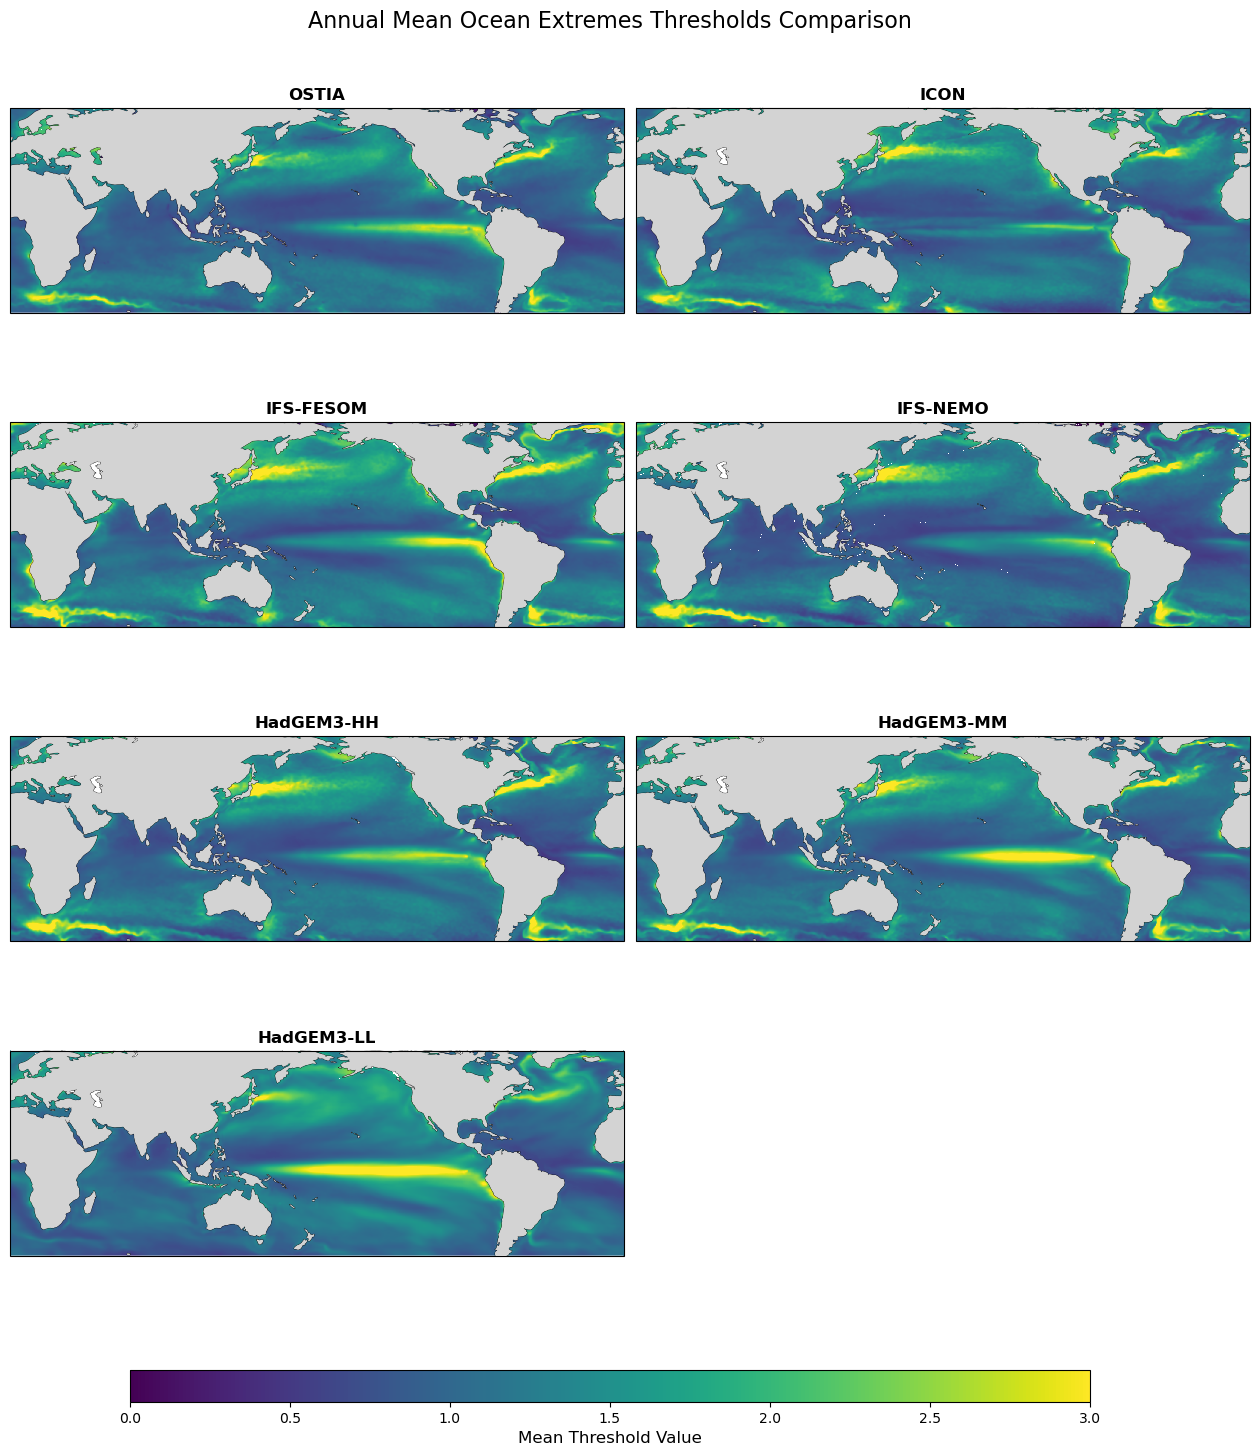

In [49]:

import math

# 1. Determine grid dimensions
num_models = len(model_data_mapping)
ncols = 2
nrows = math.ceil(num_models / ncols)

# 2. Setup the figure
# gridspec_kw={'wspace': 0.05, 'hspace': 0.1} brings subplots closer
fig, axes = plt.subplots(
    nrows=nrows, 
    ncols=ncols, 
    figsize=(16, 4 * nrows), 
    subplot_kw={'projection': ccrs.PlateCarree(central_longitude=180)},
    gridspec_kw={'wspace': 0.02, 'hspace': 0.15} 
)

axes_flat = axes.flatten()

# 3. Iterate and Plot
im = None # Placeholder for the mappable object for the colorbar
for i, (model_name, data_dict) in enumerate(model_data_mapping.items()):
    ax = axes_flat[i]
    
    da = data_dict['thresholds']
    mean_da = da.mean(dim='dayofyear')
    
    # Use vmin/vmax for common scale and add_colorbar=False
    im = mean_da.plot(
        ax=ax,
        transform=ccrs.PlateCarree(),
        add_colorbar=False, 
        vmin=0, 
        vmax=3,
        cmap='viridis',
        robust=False # Set to False since we are manually defining limits
    )
    
    ax.coastlines(resolution='110m', linewidth=0.5)
    ax.add_feature(cfeature.LAND, facecolor='lightgray', zorder=2)
    ax.set_title(model_name, fontsize=12, fontweight='bold')

# 4. Cleanup empty axes
for j in range(i + 1, len(axes_flat)):
    fig.delaxes(axes_flat[j])

# 5. Add a single common colorbar
# We use 'im' (the last plotted object) as it shares the same 0-3 scale
cbar_ax = fig.add_axes([0.2, 0.05, 0.6, 0.02]) # [left, bottom, width, height]
cbar = fig.colorbar(im, cax=cbar_ax, orientation='horizontal')
cbar.set_label('Mean Threshold Value', fontsize=12)

plt.suptitle('Annual Mean Ocean Extremes Thresholds Comparison', fontsize=16, y=0.92)

# Adjust layout to make room for colorbar at bottom
plt.subplots_adjust(bottom=0.12)

plt.show()

Processing ICON...
Processing IFS-FESOM...
Processing IFS-NEMO...
Processing HadGEM3-HH...


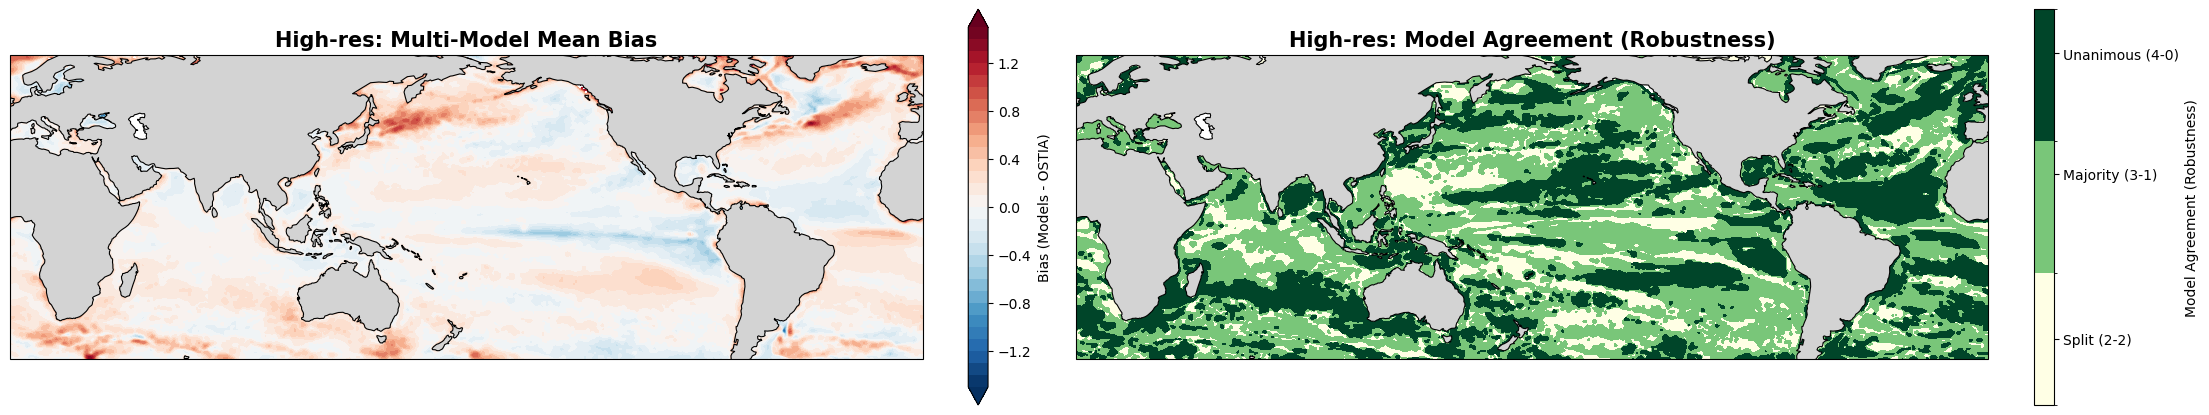

In [69]:

from cartopy.util import add_cyclic_point

# 1. Setup Models and Calculate Anomolies
high_res_models = ['ICON', 'IFS-FESOM', 'IFS-NEMO', 'HadGEM3-HH']
ostia_mean = model_data_mapping['OSTIA']['thresholds'].mean(dim='dayofyear').compute()

anomalies = []
for name in high_res_models:
    print(f"Processing {name}...")
    model_mean = model_data_mapping[name]['thresholds'].mean(dim='dayofyear')
    model_aligned = model_mean.interp_like(ostia_mean, method='linear')
    bias = (model_aligned - ostia_mean).compute()
    anomalies.append(bias)

# 2. Combine and Calculate Statistics
bias_ds = xr.concat(anomalies, dim='model')
mmm_bias = bias_ds.mean(dim='model').sortby('lon')

# Agreement Logic: Count max sign consistency
pos_count = (bias_ds > 0).sum(dim='model')
neg_count = (bias_ds < 0).sum(dim='model')
agreement_fraction = xr.where(pos_count >= neg_count, pos_count, neg_count) / len(high_res_models)
agreement_fraction = agreement_fraction.sortby('lon')

# 3. Helper to add cyclic point
def get_cyclic_data(da):
    vals, lons = add_cyclic_point(da.values, coord=da.lon.values)
    return lons, da.lat.values, vals

# 4. Setup Plot
fig, (ax1, ax2) = plt.subplots(
    nrows=1, ncols=2, figsize=(22, 8),
    subplot_kw={'projection': ccrs.PlateCarree(central_longitude=180)},
    constrained_layout=True
)

# --- Plot A: MMM Bias ---
lon1, lat1, data1 = get_cyclic_data(mmm_bias)
im1 = ax1.contourf(
    lon1, lat1, data1, 
    levels=np.linspace(-1.5, 1.5, 31), 
    cmap='RdBu_r', extend='both',
    transform=ccrs.PlateCarree()
)
plt.colorbar(im1, ax=ax1, label='Bias (Models - OSTIA)', shrink=0.5)
ax1.set_title('High-res: Multi-Model Mean Bias', fontsize=15, fontweight='bold')

# --- Plot B: Agreement (Discrete Color Fix) ---
agreement_masked = agreement_fraction.where(mmm_bias.notnull())
lon2, lat2, data2 = get_cyclic_data(agreement_masked)

# Define boundaries to "trap" the discrete fractions (0.5, 0.75, 1.0)
# We use [0.4, 0.6] for the 0.5 bin, [0.6, 0.8] for 0.75, and [0.8, 1.1] for 1.0
bounds = [0.4, 0.6, 0.8, 1.1]
cmap_agreement = plt.get_cmap('YlGn')
norm_agreement = mcolors.BoundaryNorm(bounds, cmap_agreement.N)

im2 = ax2.contourf(
    lon2, lat2, data2, 
    levels=bounds, 
    cmap=cmap_agreement, 
    norm=norm_agreement,
    transform=ccrs.PlateCarree()
)

# Custom colorbar with specific tick labels centered in the blocks
cbar2 = plt.colorbar(im2, ax=ax2, shrink=0.5, ticks=[0.5, 0.75, 1.0])
cbar2.ax.set_yticklabels(['Split (2-2)', 'Majority (3-1)', 'Unanimous (4-0)'])
cbar2.set_label('Model Agreement (Robustness)')
ax2.set_title('High-res: Model Agreement (Robustness)', fontsize=15, fontweight='bold')

# --- Final Formatting and Extent Fix ---
# Use explicit coordinates to ensure both plots cut off at the exact same latitudes
extent = [-180, 180, -50, 70] 

for ax in [ax1, ax2]:
    ax.set_extent(extent, crs=ccrs.PlateCarree())
    ax.coastlines(resolution='110m', linewidth=0.8, zorder=3)
    ax.add_feature(cfeature.LAND, facecolor='lightgray', zorder=2)

plt.show()

In [49]:


# 1. Setup Models and Calculate Anomolies
high_res_models = ['ICON', 'IFS-FESOM', 'IFS-NEMO', 'HadGEM3-HH']
ostia_mean = model_data_mapping['OSTIA']['thresholds'].mean(dim='dayofyear').compute()

anomalies = []
for name in high_res_models:
    print(f"Processing {name}...")
    model_mean = model_data_mapping[name]['thresholds'].mean(dim='dayofyear')
    model_aligned = model_mean.interp_like(ostia_mean, method='linear')
    bias = (model_aligned - ostia_mean).compute()
    anomalies.append(bias)

# 2. Combine and Calculate Statistics
bias_ds = xr.concat(anomalies, dim='model')
mmm_bias = bias_ds.mean(dim='model').sortby('lon')

# Agreement Logic: Count max sign consistency
pos_count = (bias_ds > 0).sum(dim='model')
neg_count = (bias_ds < 0).sum(dim='model')
agreement_fraction = xr.where(pos_count >= neg_count, pos_count, neg_count) / len(high_res_models)
agreement_fraction = agreement_fraction.sortby('lon')

Processing ICON...
Processing IFS-FESOM...
Processing IFS-NEMO...
Processing HadGEM3-HH...


<>:35: SyntaxWarning: "\c" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\c"? A raw string is also an option.
<>:35: SyntaxWarning: "\c" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\c"? A raw string is also an option.
/tmp/ipykernel_3141791/1170459730.py:35: SyntaxWarning: "\c" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\c"? A raw string is also an option.
  plt.colorbar(im, label='Bias (Models - OSTIA) [$^\circ C$]', shrink=0.5, pad=0.02)


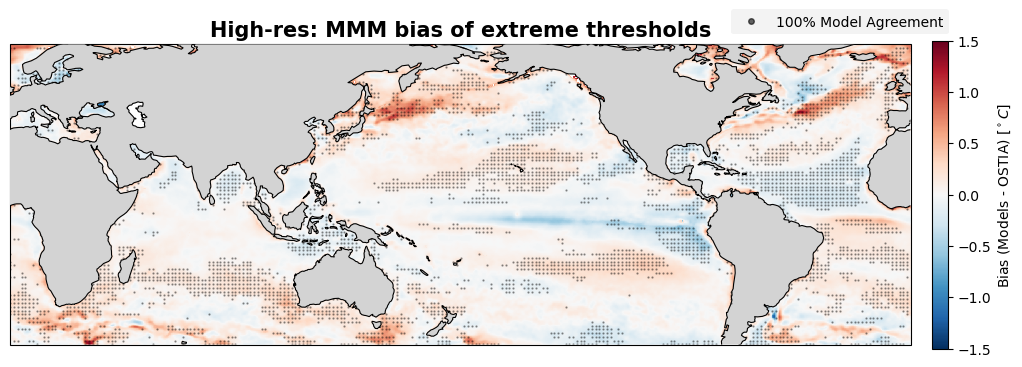

In [50]:

# --- 1. Setup Plot ---
plt.figure(figsize=(14, 8))
ax = plt.axes(projection=ccrs.PlateCarree(central_longitude=180))

# --- 2. Layer 1: Multi-Model Mean Bias ---
# Using .plot() directly on the DataArray avoids the 'contourf' dateline gap
im = mmm_bias.plot(
    ax=ax, 
    transform=ccrs.PlateCarree(),
    cmap='RdBu_r', 
    vmin=-1.5, vmax=1.5,
    add_colorbar=False,
    zorder=1
)

# --- 3. Layer 2: Stippling ---
# Use the original agreement_fraction (no manual wrap) to avoid double-dots
skip = 6
stipple_data = agreement_fraction.where(mmm_bias.notnull()).isel(
    lat=slice(None, None, skip), 
    lon=slice(None, None, skip)
)
lon_mesh, lat_mesh = np.meshgrid(stipple_data.lon, stipple_data.lat)
stipple_mask = stipple_data.values == 1.0

ax.scatter(
    lon_mesh[stipple_mask], 
    lat_mesh[stipple_mask], 
    color='black', marker='.', s=1.5, alpha=0.4, 
    transform=ccrs.PlateCarree(),
    zorder=4
)

# --- 4. Formatting ---
plt.colorbar(im, label='Bias (Models - OSTIA) [$^\circ C$]', shrink=0.5, pad=0.02)

# --- 5. Legend to the right of the title with gray background ---
stipple_proxy = mlines.Line2D([], [], color='black', marker='.', linestyle='None',
                              markersize=8, alpha=0.6, label='100% Model Agreement')

ax.legend(handles=[stipple_proxy], 
          loc='lower right', 
          bbox_to_anchor=(1.05, 1.01), 
          frameon=True,
          facecolor='#f0f0f0',
          edgecolor='none',
          fontsize=10)

# Center the title as requested
ax.set_title('High-res: MMM bias of extreme thresholds', loc='center', fontsize=15, fontweight='bold')

# Geographic features & Extent
ax.set_extent([-180, 180, -50, 70], crs=ccrs.PlateCarree())
ax.coastlines(resolution='110m', linewidth=0.8, zorder=5)
ax.add_feature(cfeature.LAND, facecolor='lightgray', zorder=3)

plt.show()

In [ ]:
# LOW RES

Processing HadGEM3-MM...
Processing HadGEM3-LL...


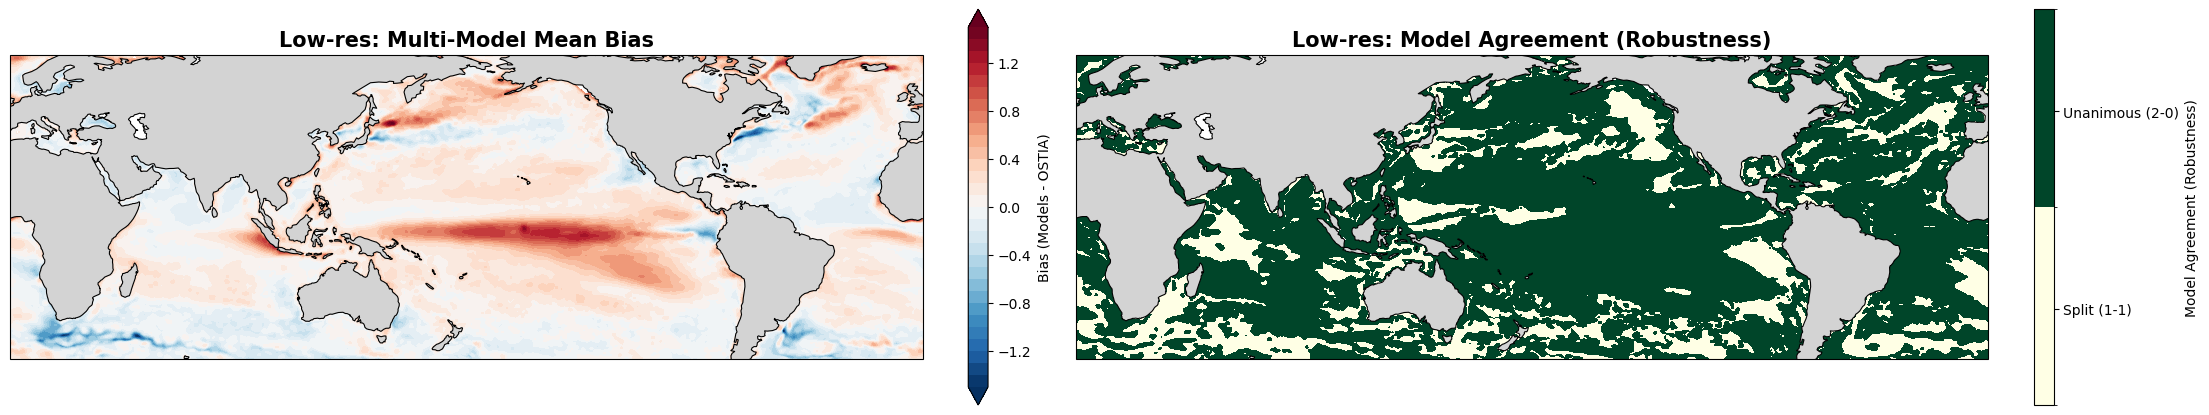

In [71]:


# 1. Setup Low-Res Models
low_res_models = ['HadGEM3-MM', 'HadGEM3-LL']

# Use OSTIA as the master reference grid
ostia_mean = model_data_mapping['OSTIA']['thresholds'].mean(dim='dayofyear').compute()

anomalies = []
for name in low_res_models:
    print(f"Processing {name}...")
    
    # Calculate model mean
    model_mean = model_data_mapping[name]['thresholds'].mean(dim='dayofyear')
    
    # Interpolate model to OSTIA grid to handle resolution differences
    model_aligned = model_mean.interp_like(ostia_mean, method='linear')
    
    # Compute bias and store
    bias = (model_aligned - ostia_mean).compute()
    anomalies.append(bias)

# 2. Combine and Calculate Statistics
bias_ds = xr.concat(anomalies, dim='model')
mmm_bias = bias_ds.mean(dim='model').sortby('lon')

# Agreement Logic: For 2 models, agreement is either 0.5 (1-1 split) or 1.0 (2-0 agree)
pos_count = (bias_ds > 0).sum(dim='model')
neg_count = (bias_ds < 0).sum(dim='model')
agreement_fraction = xr.where(pos_count >= neg_count, pos_count, neg_count) / len(low_res_models)
agreement_fraction = agreement_fraction.sortby('lon')

# 3. Helper to add cyclic point for seamless maps
def get_cyclic_data(da):
    vals, lons = add_cyclic_point(da.values, coord=da.lon.values)
    return lons, da.lat.values, vals

# 4. Setup Plot
fig, (ax1, ax2) = plt.subplots(
    nrows=1, ncols=2, figsize=(22, 8),
    subplot_kw={'projection': ccrs.PlateCarree(central_longitude=180)},
    constrained_layout=True
)

# --- Plot A: MMM Bias (Low-Res) ---
lon1, lat1, data1 = get_cyclic_data(mmm_bias)
im1 = ax1.contourf(
    lon1, lat1, data1, 
    levels=np.linspace(-1.5, 1.5, 31), 
    cmap='RdBu_r', extend='both',
    transform=ccrs.PlateCarree()
)
plt.colorbar(im1, ax=ax1, label='Bias (Models - OSTIA)', shrink=0.5)
ax1.set_title('Low-res: Multi-Model Mean Bias', fontsize=15, fontweight='bold')

# --- Plot B: Agreement (Discrete Color Fix) ---
agreement_masked = agreement_fraction.where(mmm_bias.notnull())
lon2, lat2, data2 = get_cyclic_data(agreement_masked)

# For 2 models, we only have two levels of agreement: 0.5 and 1.0
# We define bounds to create two distinct color blocks
bounds = [0.4, 0.75, 1.1] 
cmap_agreement = plt.get_cmap('YlGn')
norm_agreement = mcolors.BoundaryNorm(bounds, cmap_agreement.N)

im2 = ax2.contourf(
    lon2, lat2, data2, 
    levels=bounds, 
    cmap=cmap_agreement, 
    norm=norm_agreement,
    transform=ccrs.PlateCarree()
)

# Colorbar with labels for 1 vs 2 models
cbar2 = plt.colorbar(im2, ax=ax2, shrink=0.5, ticks=[0.57, 0.92]) # Centered in blocks
cbar2.ax.set_yticklabels(['Split (1-1)', 'Unanimous (2-0)'])
cbar2.set_label('Model Agreement (Robustness)')
ax2.set_title('Low-res: Model Agreement (Robustness)', fontsize=15, fontweight='bold')

# --- Final Formatting and Extent Fix ---
# Match the exact latitude/longitude crop of your previous plots
extent = [-180, 180, -50, 70] 

for ax in [ax1, ax2]:
    ax.set_extent(extent, crs=ccrs.PlateCarree())
    ax.coastlines(resolution='110m', linewidth=0.8, zorder=3)
    ax.add_feature(cfeature.LAND, facecolor='lightgray', zorder=2)

plt.show()

<>:35: SyntaxWarning: "\c" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\c"? A raw string is also an option.
<>:35: SyntaxWarning: "\c" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\c"? A raw string is also an option.
/tmp/ipykernel_3141791/1790300958.py:35: SyntaxWarning: "\c" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\c"? A raw string is also an option.
  plt.colorbar(im, label='Bias (Models - OSTIA) [$^\circ C$]', shrink=0.5, pad=0.02)


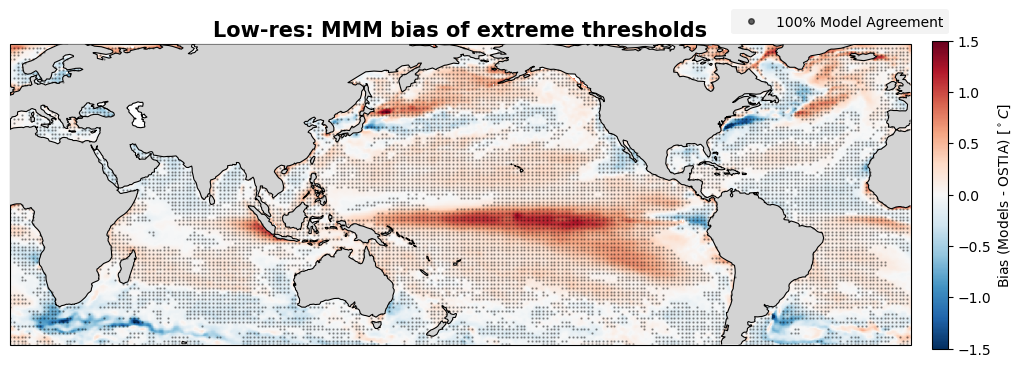

In [48]:

# --- 1. Setup Plot ---
plt.figure(figsize=(14, 8))
ax = plt.axes(projection=ccrs.PlateCarree(central_longitude=180))

# --- 2. Layer 1: Multi-Model Mean Bias ---
# Using .plot() directly on the DataArray avoids the 'contourf' dateline gap
im = mmm_bias.plot(
    ax=ax, 
    transform=ccrs.PlateCarree(),
    cmap='RdBu_r', 
    vmin=-1.5, vmax=1.5,
    add_colorbar=False,
    zorder=1
)

# --- 3. Layer 2: Stippling ---
# Use the original agreement_fraction (no manual wrap) to avoid double-dots
skip = 6
stipple_data = agreement_fraction.where(mmm_bias.notnull()).isel(
    lat=slice(None, None, skip), 
    lon=slice(None, None, skip)
)
lon_mesh, lat_mesh = np.meshgrid(stipple_data.lon, stipple_data.lat)
stipple_mask = stipple_data.values == 1.0

ax.scatter(
    lon_mesh[stipple_mask], 
    lat_mesh[stipple_mask], 
    color='black', marker='.', s=1.5, alpha=0.4, 
    transform=ccrs.PlateCarree(),
    zorder=4
)

# --- 4. Formatting ---
plt.colorbar(im, label='Bias (Models - OSTIA) [$^\circ C$]', shrink=0.5, pad=0.02)

# --- 5. Legend to the right of the title with gray background ---
stipple_proxy = mlines.Line2D([], [], color='black', marker='.', linestyle='None',
                              markersize=8, alpha=0.6, label='100% Model Agreement')

ax.legend(handles=[stipple_proxy], 
          loc='lower right', 
          bbox_to_anchor=(1.05, 1.01), 
          frameon=True,
          facecolor='#f0f0f0',
          edgecolor='none',
          fontsize=10)

# Center the title as requested
ax.set_title('Low-res: MMM bias of extreme thresholds', loc='center', fontsize=15, fontweight='bold')

# Geographic features & Extent
ax.set_extent([-180, 180, -50, 70], crs=ccrs.PlateCarree())
ax.coastlines(resolution='110m', linewidth=0.8, zorder=5)
ax.add_feature(cfeature.LAND, facecolor='lightgray', zorder=3)

plt.show()